## Chapter 5 Evaluating Predictive Performance

**Original Code Credit:**: Shmueli, Galit; Bruce, Peter C.; Gedeck, Peter; Patel, Nitin R.. Machine Learning for Business Analytics Wiley.

*Modifications* have been made from the original textbook examples due to version changes in library dependencies and/or for clarity.

### Import Libraries

In [1]:
import os
import math
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pylab as plt
from dmba import regressionSummary, classificationSummary
#from dmba import liftChart, gainsChart
import mlba
import matplotlib

%matplotlib inline

### 5.3 Judging Classifier Performance

In [2]:
owner_df = pd.read_csv(os.path.join('..', 'data', 'ownerExample.csv'))
owner_df

,Class,Probability
0,owner,0.9959
1,owner,0.9875
2,owner,0.9844
3,owner,0.9804
4,owner,0.9481
5,owner,0.8892
6,owner,0.8476
7,nonowner,0.7628
8,owner,0.7069
9,owner,0.6807


In [3]:
## cutoff = 0.5
predicted = ['owner' if p > 0.5 else 'nonowner' for p in owner_df.Probability]
classificationSummary(owner_df.Class, predicted, class_names=['nonowner', 'owner'])

Confusion Matrix (Accuracy 0.8750)

         Prediction
  Actual nonowner    owner
nonowner       10        2
   owner        1       11


In [4]:
## cutoff = 0.25               
predicted = ['owner' if p > 0.25 else 'nonowner' for p in owner_df.Probability]
classificationSummary(owner_df.Class, predicted, class_names=['nonowner', 'owner'])

Confusion Matrix (Accuracy 0.7917)

         Prediction
  Actual nonowner    owner
nonowner        8        4
   owner        1       11


In [5]:
## cutoff = 0.75
predicted = ['owner' if p > 0.75 else 'nonowner' for p in owner_df.Probability]
classificationSummary(owner_df.Class, predicted, class_names=['nonowner', 'owner'])


Confusion Matrix (Accuracy 0.7500)

         Prediction
  Actual nonowner    owner
nonowner       11        1
   owner        5        7


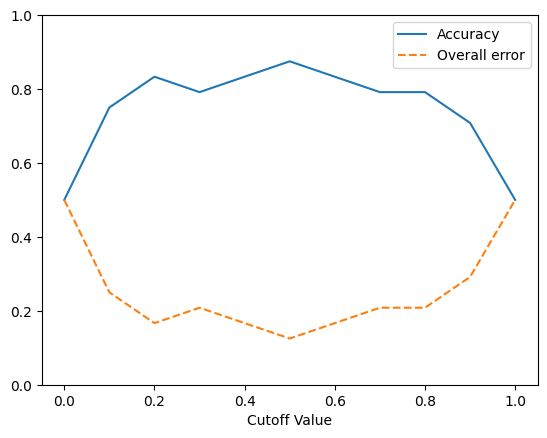

In [6]:
df = pd.read_csv(os.path.join('..', 'data', 'liftExample.csv'))

cutoffs = [i * 0.1 for i in range(0, 11)]
accT = []
for cutoff in cutoffs:
    predicted = [1 if p > cutoff else 0 for p in df.prob]
    accT.append(accuracy_score(df.actual, predicted))

line_accuracy = plt.plot(cutoffs, accT, '-', label='Accuracy')[0]
line_error = plt.plot(cutoffs, [1 - acc for acc in accT], '--', label='Overall error')[0]
plt.ylim([0,1])
plt.xlabel('Cutoff Value')
plt.legend(handles=[line_accuracy, line_error])
plt.show()

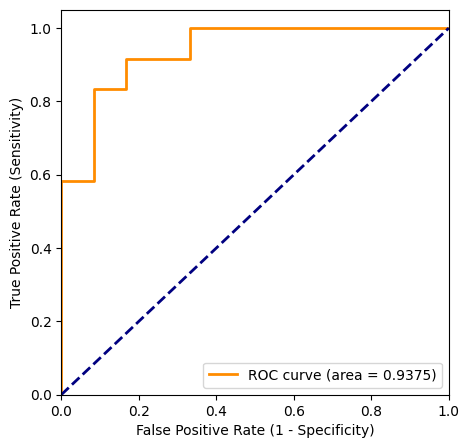

In [7]:
# compute ROC curve and AUC
fpr, tpr, _ = roc_curve(df.actual, df.prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=[5, 5])
plt.plot(fpr, tpr, color='darkorange',
         lw=2, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc="lower right")
plt.show()

### 5.4 Judging Ranking Performance


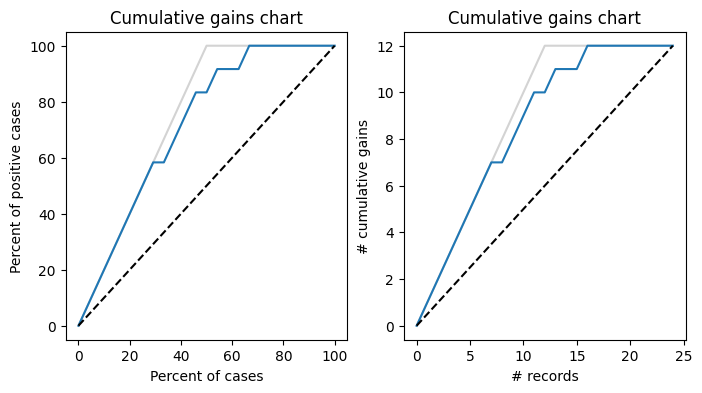

In [8]:
df = df.sort_values(by=['prob'], ascending=False)
fig, axes = plt.subplots(ncols=2, figsize=(8, 4))
mlba.gainsChart(df, ranking='prob', actual='actual', ax=axes[0])
mlba.gainsChart(df, ranking='prob', actual='actual', show_counts=True, ax=axes[1])
plt.show()

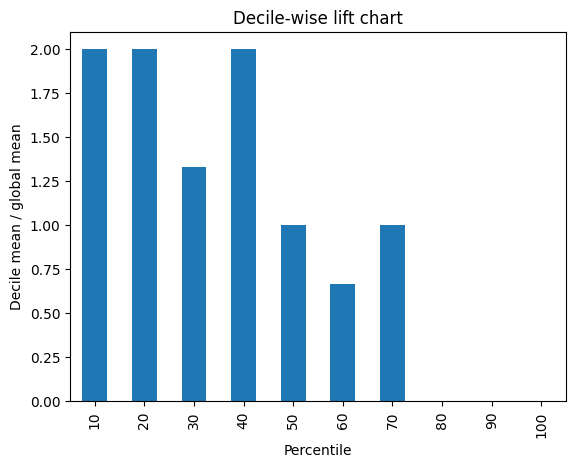

In [9]:
# use liftChart method from utilities
mlba.liftChart(df, ranking='prob', actual='actual', labelBars=False)
plt.show()